### Задание 2
Загрузите датасет и проведите первичный анализ, чтобы лучше понять структуру датасета и оценить эффективность проведённого A/B-теста:
Посмотрите распределение целевой переменной target (факт перехода клиента на тариф Комфорт) в разрезе контрольной и тестовой групп с помощью функции groupby в pandas. Это позволит оценить, насколько эффективным было маркетинговое воздействие.
Проверьте датасет на пропущенные значения, чтобы убедиться в качестве данных перед построением модели.
Эти шаги помогут понять, есть ли статистически значимая разница между группами, а также подготовить данные для дальнейшего моделирования.

In [1]:
import pandas as pd
# загружаем данные
data = pd.read_csv("ab_results.csv")

grouped_data = (data
    .groupby('treatment')['target']  # 0 — контроль, 1 — тестовая группа
    .agg(['count', 'sum', 'mean'])   # размер группы, число переходов, конверсия
)
print(data.isnull().sum())  # количество пропущенных значений по столбцам
print(grouped_data)  # сгруппированные данные


usage_duration                     0
number_of_bank_cards               0
money_spent_amount                 0
visit_frequency                    0
number_of_visited_shops            0
number_of_viewed_communications    0
age                                0
treatment                          0
target                             0
dtype: int64
            count    sum      mean
treatment                         
0          200000  38743  0.193715
1          200000  58799  0.293995


Размер групп сбалансирован: 
- В обеих группах (treatment = 0 и treatment = 1) находится ровно по 200 000 пользователей.
- Конверсия в контрольной группе (treatment = 0): mean = 0.1937 (около 19.4%).
- Конверсия в тестовой группе (treatment = 1): mean = 0.2940 (около 29.4%).
- Чистый эффект: Разница составляет \(29.4\% - 19.4\% = 10\%\) (в процентных пунктах), что наглядно подтверждает сильный положительный эффект от маркетингового воздействия.

### Задание 4
Запустите следующий код для построения матрицы корреляций.

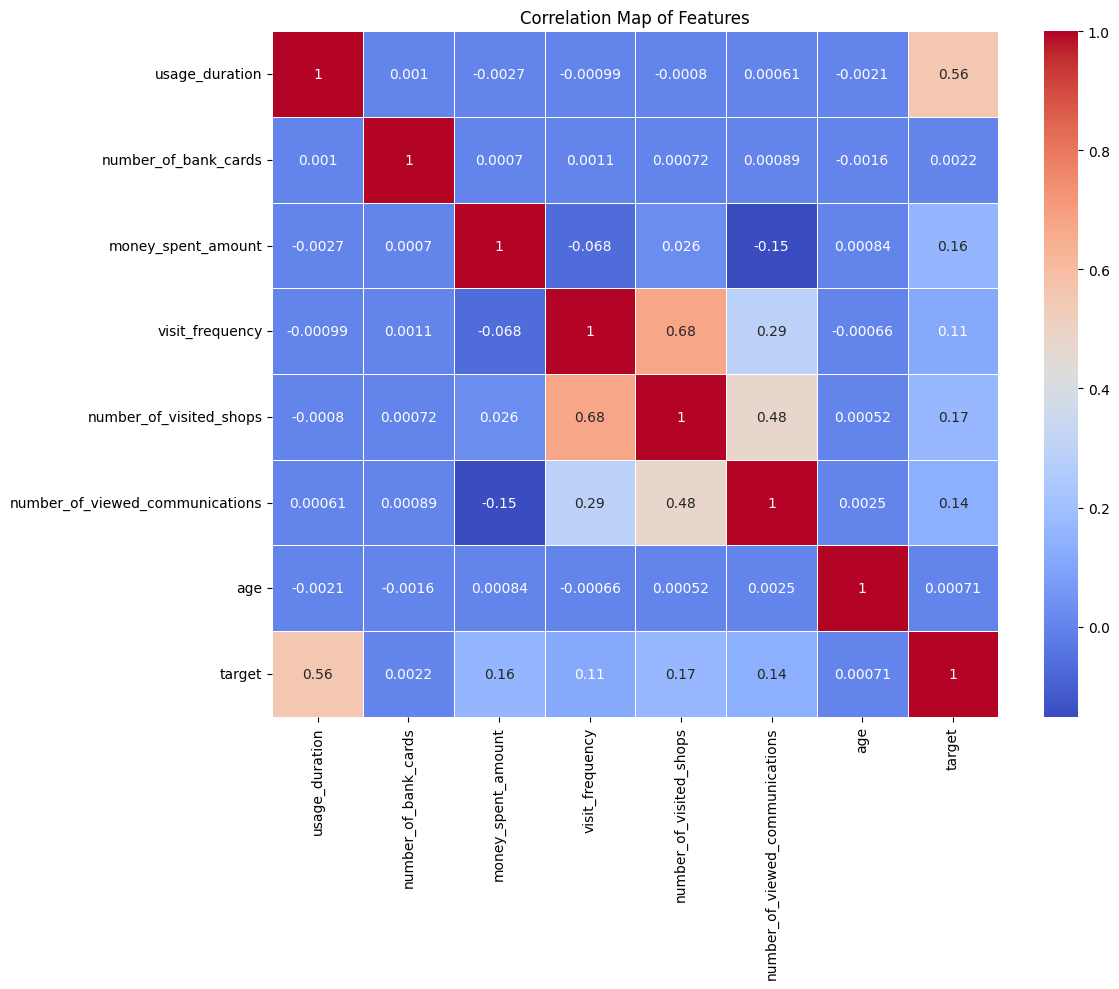

In [2]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

# загружаем данные
data = pd.read_csv("ab_results.csv")

plt.figure(figsize=(12, 10))
correlation_matrix = (data
                     .drop(columns=['treatment'])
                     .corr()
                    )
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Map of Features')
plt.tight_layout()
plt.show() 

Какая фича имеет наибольшую корреляцию с таргетом? usage_duration

### Реализация обучения uplift-деревьев
Чтобы реализовать uplift-деревья, нам потребуется класс модели UpliftRandomForestClassifier, доступный в модуле inference.tree библиотеки causalm

In [3]:
from causalml.inference.tree import UpliftRandomForestClassifier 
import pandas as pd

# загрузка датасета
data = pd.read_csv("ab_results.csv")

# разделение на признаки и целевую переменную
X = data.drop(['target'], axis=1)
y = data['target'] 

### Задание 6
Оцените, какие уникальные значения хранятся в целевой переменной (колонка - treatment).

In [4]:
uniq_y = y.unique()  # уникальные метки групп воздействия: 0 — контроль, 1 — тест
print(uniq_y) 

[0 1]


In [5]:
from sklearn.model_selection import train_test_split
# разделение на обучающую и валидационную выборки
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.3, random_state=42)

# causalml склеивает имена групп со строками: 0/1 (int) дают TypeError
# control_name='control', поэтому контрольная группа должна называться 'control'
X_train = X_train.copy()
X_val = X_val.copy()
X_train['treatment'] = X_train['treatment'].map({0: 'control', 1: 'treatment'})
X_val['treatment'] = X_val['treatment'].map({0: 'control', 1: 'treatment'})

# создаём модель Uplift Random Forest, указывая название контрольной группы
uplift_model = UpliftRandomForestClassifier(control_name = 'control')

Обратите внимание, что при инициализации модели использовался параметр control_name, которому присвоили значение control. Это нужно, чтобы явно передать в модель название контрольной группы. Следующий шаг — обучение модели. Для этого нужно передать признаки без столбца treatment, отдельно передать информацию о принадлежности к группе воздействия, передать целевую переменную (конверсию).

In [6]:
uplift_model.fit(X_train.drop(columns=['treatment']).values,
                 treatment=X_train['treatment'].values,
                 y=y_train.values)

### Задание 7
Получите предсказания для обученной модели и напечатайте их. Обученная ранее модель уже хранится в вашем juputer ноутбуке, поэтому результат выполнения предыдущего задания не нужно удалять.
Получение предсказаний для uplift-моделей из библиотеки causalml ничем не отличается от стандартного получения предсказаний для любой другой классической модели машинного обучения. Вызовите метод predict(), который позволит вам сделать предсказания, и подайте ему валидационные данные как параметр (не забудьте исключить из них колонку treatment), а также установите значение параметра full_output=False. Чуть позже мы расскажем, для чего это нужно.

In [8]:
# предсказания обученной модели на валидации; колонку treatment не подаём
uplift_scores = uplift_model.predict(
    X_val.drop(columns=['treatment']),
    full_output=False  # вернуть только uplift-скоры
)
print(uplift_scores)

[[0.04473732]
 [0.73779315]
 [0.04414627]
 ...
 [0.01907938]
 [0.01907938]
 [0.95537071]]


### Задание 8
Ранее вы выделяли топ-5% клиентов по uplift-скору.

In [9]:
import numpy as np
top_percent = 0.05

# сортируем массив в убывающем порядке
top_5_percent = np.sort(uplift_scores.ravel())[::-1][:int(len(uplift_scores) * top_percent)]

print(f"Количество клиентов в верхних 5%: {len(top_5_percent)}")
print(f"Минимальное значение uplift в верхних 5%: {np.min(top_5_percent):.2f}")
print(f"Максимальное значение uplift в верхних 5%: {np.max(top_5_percent):.2f}")
print(f"Среднее значение uplift: {np.mean(top_5_percent):.2f}")

Количество клиентов в верхних 5%: 6000
Минимальное значение uplift в верхних 5%: 0.73
Максимальное значение uplift в верхних 5%: 0.97
Среднее значение uplift: 0.92


### Задание 10
Постройте график uplift-кривой. Предсказания модели для валидационной выборки сохранены в файл predictions.csv. Датасет уже прочитан и разделён на валидационный и тренировочный наборы, то есть вам доступны к использованию переменные X_train, X_val, y_train, y_val. Загрузите предсказания и поместите их в переменную uplift_preds. Данные о воздействии поместите в переменную treatment из X_val. 

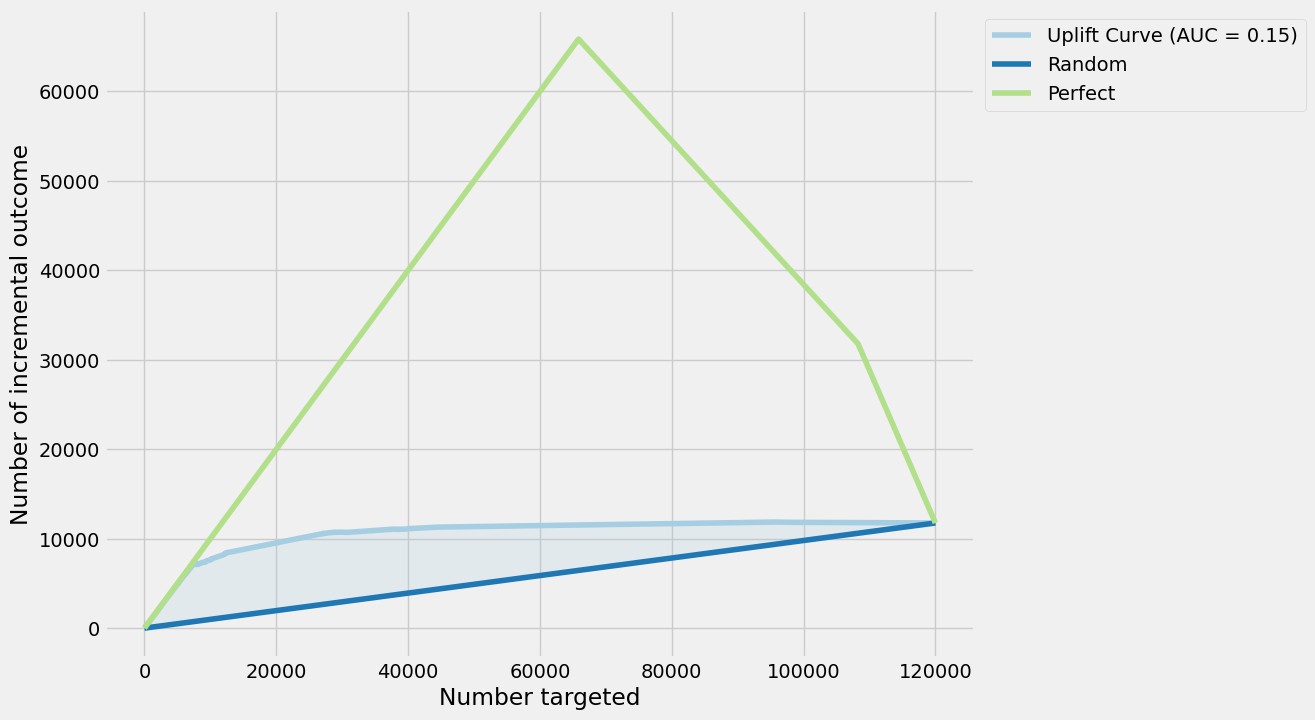

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
from sklift.viz import plot_uplift_curve

fig, axs = plt.subplots(1, 1, figsize=(10, 8))

# загрузите predictions.csv
uplift_preds = pd.read_csv("predictions_less4.csv")["preds"]  # предсказания модели на валидации
treatment = X_val["treatment"]  # факт воздействия (control/treatment) из X_val

treatment_mapping = {
    'control': 0, 
     'treatment': 1,  
}

#  применяем маппинг к столбцу treatment
treatment = treatment.map(treatment_mapping)

# постройте график uplift-кривой
# y_val — факт конверсии, uplift_preds — скоры модели, treatment — группа воздействия
plot_uplift_curve(
    y_val,
    uplift_preds,
    treatment,
    perfect=True,
    ax=axs,
    name='Uplift Curve'
) 



значения AUC для uplift-кривой?
Правильный ответ
0.15

### Задание 12
Постройте график Qini-кривой. Датасет уже прочитан и разделён на валидационный и тренировочный наборы в ранее выполненных заданиях, то есть вам доступны к использованию переменные X_train, X_val, y_train, y_val. 

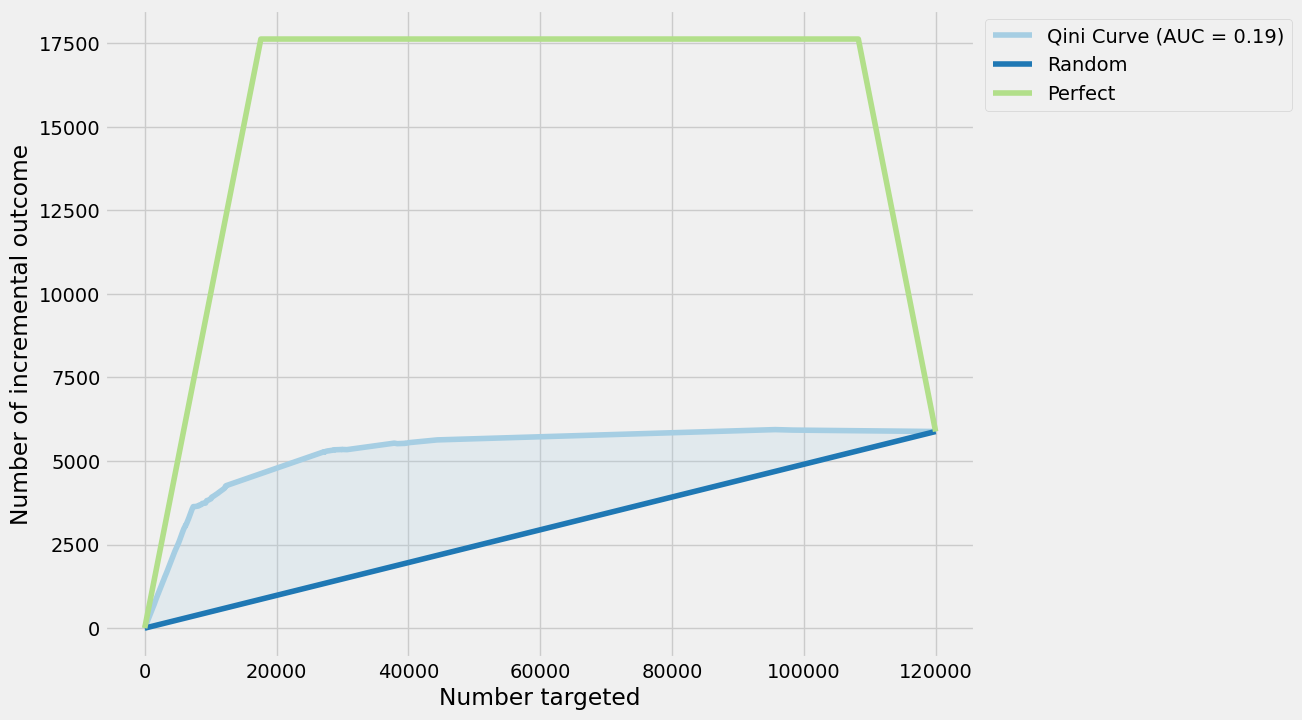

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklift.viz import plot_qini_curve

fig, axs = plt.subplots(1, 1, figsize=(10, 8))

# те же предсказания и treatment, что для uplift-кривой
uplift_preds = pd.read_csv("predictions_less4.csv")["preds"]
# 0/1 или 'control'/'treatment' — приводим к бинарному treatment
treatment = X_val["treatment"].map({"control": 0, "treatment": 1}).fillna(X_val["treatment"])

# постройте график Qini-кривой
plot_qini_curve(
    y_val,
    uplift_preds,
    treatment,
    perfect=True,
    ax=axs,
    name="Qini Curve"
)


In [ ]:
значения AUC для Qini-кривой?
Правильный ответ
0.19